In [2]:
# ============================================
# Natural Gas Price Analysis & Forecast
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [4]:
# 1. Load CSV
# --------------------------------------------
df = pd.read_csv("nat_gas.csv")  # change filename if needed

# Convert date column
df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

# Set index
df.set_index("Dates", inplace=True)

# Clean price (handles scientific notation automatically)
df["Prices"] = df["Prices"].astype(float)

print(df.head())

            Prices
Dates             
2020-10-31    10.1
2020-11-30    10.3
2020-12-31    11.0
2021-01-31    10.9
2021-02-28    10.9


C:\Users\makwa\AppData\Local\Temp\ipykernel_29200\2116662929.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


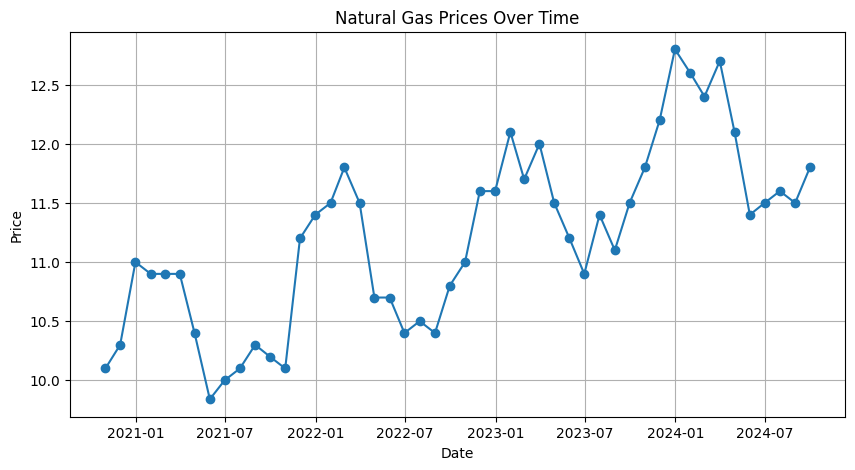

In [6]:
# --------------------------------------------
# 2. Plot data
# --------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Prices"], marker="o")
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [8]:
# --------------------------------------------
# 3. Feature engineering
# --------------------------------------------
df["t"] = np.arange(len(df))        # time trend
df["month"] = df.index.month        # seasonality

# one-hot encode month
month_dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)

# build features
X = pd.concat([df["t"], month_dummies], axis=1)
y = df["Prices"]

In [10]:
# --------------------------------------------
# 4. Train model
# --------------------------------------------
model = LinearRegression()
model.fit(X, y)

print("Model trained!")

Model trained!


In [12]:
# --------------------------------------------
# 5. Prediction function
# --------------------------------------------
def predict_price(date_str):
    date = pd.to_datetime(date_str)

    # interpolation (inside dataset)
    if df.index.min() <= date <= df.index.max():
        return np.interp(
            date.value,
            df.index.view(np.int64),
            df["Prices"]
        )

    # extrapolation (future)
    t = (date - df.index.min()).days / 30

    month = date.month
    month_features = [1 if i == month else 0 for i in range(2,13)]

    features = np.array([t] + month_features).reshape(1, -1)

    return model.predict(features)[0]

In [14]:
# --------------------------------------------
# 6. Test predictions
# --------------------------------------------
print("\nTest:")
print("2022-06-30:", predict_price("2022-06-30"))
print("2025-06-30:", predict_price("2025-06-30"))


Test:
2022-06-30: 11.8
2025-06-30: 12.088345833333332


c:\Users\makwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:

# --------------------------------------------
# 7. Forecast next 12 months
# --------------------------------------------
future_dates = pd.date_range(start=df.index.max(), periods=12, freq="ME")
future_prices = [predict_price(str(d)) for d in future_dates]

c:\Users\makwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\makwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\makwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\makwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\makwa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

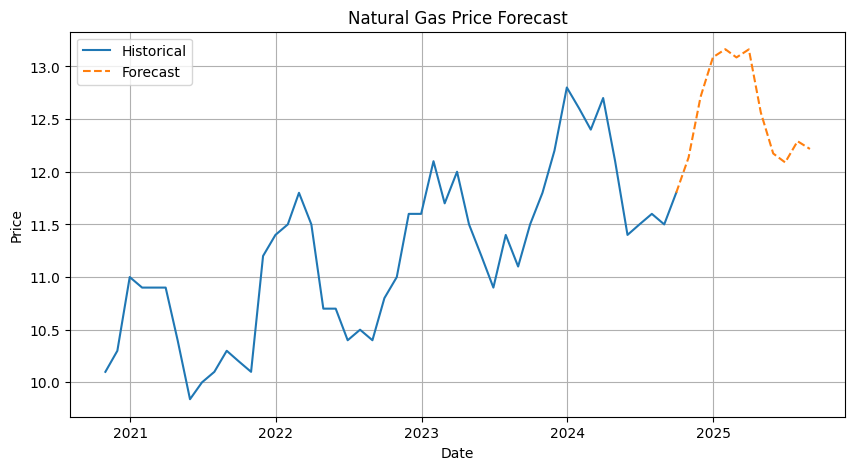

In [18]:
# --------------------------------------------
# 8. Plot forecast
# --------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Prices"], label="Historical")
plt.plot(future_dates, future_prices, linestyle="--", label="Forecast")
plt.title("Natural Gas Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()